### Research Question
- Has NFL home-field advantage decreased since the COVID-19 pandemic?

### Statistics To Consider
- Home-tean Win Percentage Per Season(Display)
- Home-team Win Percentage From 2014-2019
- Home-team Win Percentage From 2021-Present
- Is The Change Statistically Significant?

### Hypotheses
- Null: The impact of Home-field advantage remained the same pre and post covid
- Alternate: The impact of Home-field advantage lessened post covid

In [5]:
#Imports 
import glob
import os
import pandas as pd

In [8]:
#Combine The datasets
folder_path = "Season_Scores"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
df_list = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)
combined_df.columns.tolist()

['Season',
 'Week',
 'GameStatus',
 'GameSlot',
 'GameDate',
 'AwayTeam',
 'AwayScore',
 'HomeTeam',
 'HomeScore']

In [40]:
# Add a new column called "HomeTeamWin" to the combined_df DataFrame
combined_df['HomeTeamWin'] = combined_df['HomeScore'] > combined_df['AwayScore']
#Take out hall of fame and preseason games
combined_df_filtered = combined_df[~combined_df['GameStatus'].str.contains('BYE|Clinched Playoffs')]
combined_df_filtered = combined_df_filtered[~combined_df_filtered['Week'].str.contains('HALL OF FAME|PRESEASON|PRO BOWL')]
print(combined_df_filtered.head())

    Season    Week GameStatus  GameSlot        GameDate AwayTeam  AwayScore  \
65    2010  WEEK 1      FINAL  Thursday   September 9th      MIN        9.0   
66    2010  WEEK 1      FINAL    Sunday  September 12th      CLE       14.0   
67    2010  WEEK 1      FINAL    Sunday  September 12th      MIA       15.0   
68    2010  WEEK 1      FINAL    Sunday  September 12th      CIN       24.0   
69    2010  WEEK 1      FINAL    Sunday  September 12th      IND       24.0   

   HomeTeam  HomeScore  HomeTeamWin  
65       NO       14.0         True  
66       TB       17.0         True  
67      BUF       10.0        False  
68       NE       38.0         True  
69      HOU       34.0         True  


In [42]:
#For each season, provide percentage of home team wins and away team wins.
home_wins = combined_df_filtered.groupby('Season')['HomeTeamWin'].sum()
total_games = combined_df_filtered.groupby('Season')['HomeTeamWin'].count()
home_win_percentage = (home_wins / total_games) * 100
away_win_percentage = 100 - home_win_percentage
print("Home Win Percentage by Season:")
print(home_win_percentage)

Home Win Percentage by Season:
Season
2010    55.430712
2011    57.303371
2012    56.928839
2013    59.550562
2014    57.303371
2015    54.307116
2016    58.052434
2017    56.928839
2018    59.176030
2019    52.059925
2020    49.814126
2021    51.578947
2022    56.140351
2023    56.491228
2024    54.736842
2025    53.333333
Name: HomeTeamWin, dtype: float64


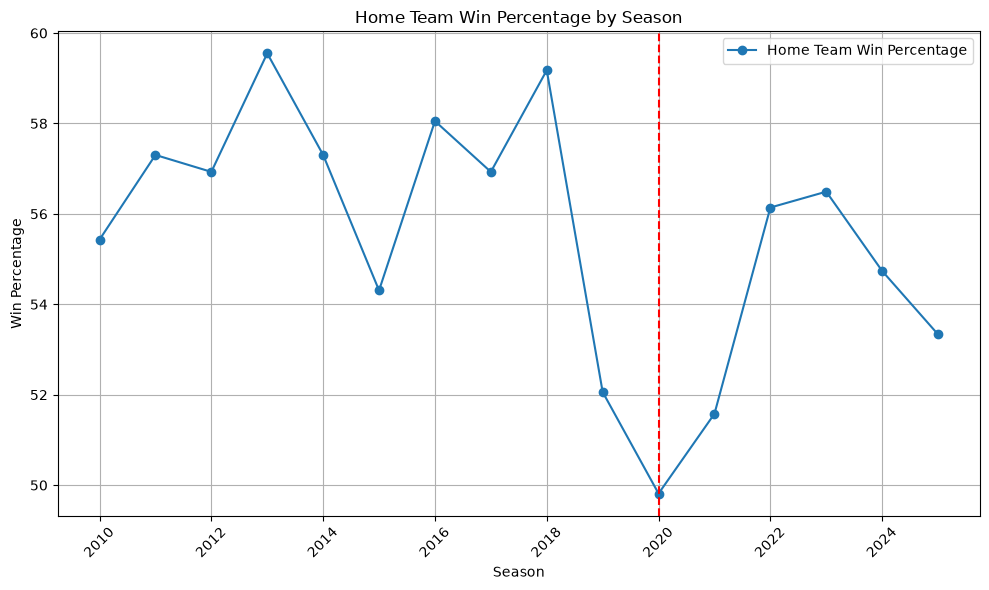

In [64]:
# Graph the home win percentage by season
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(home_win_percentage.index, home_win_percentage.values, marker='o', label='Home Team Win Percentage')
plt.title('Home Team Win Percentage by Season')
plt.xlabel('Season')
plt.ylabel('Win Percentage')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.axvline(x=2020, color='red', linestyle='--', label='2020 Season (COVID-19 Impact)')
plt.show()


Pre-COVID Home Win Percentage: 56.70%
Post-COVID Home Win Percentage: 54.46%


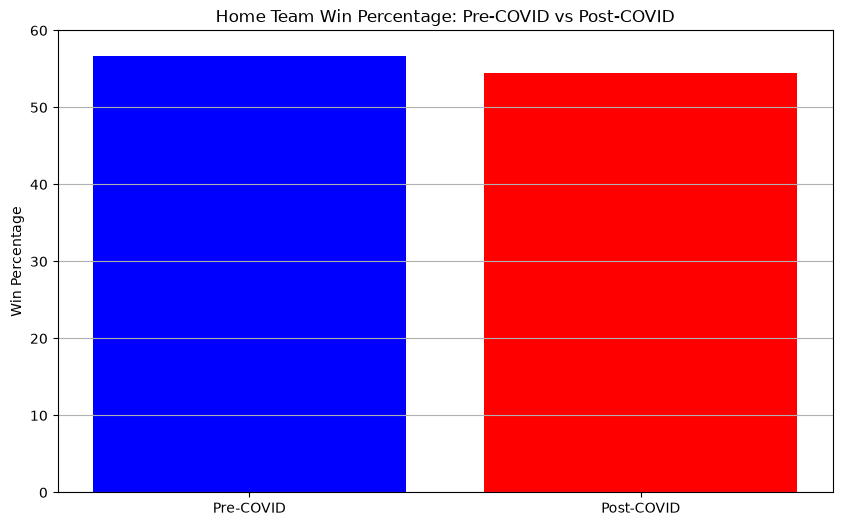

In [66]:
from scipy import stats
import numpy as np

# Split the data into pre-COVID and post-COVID seasons and calculate the home win percentage for each group
pre_covid_df = combined_df_filtered[combined_df_filtered['Season'] < 2020]
post_covid_df = combined_df_filtered[combined_df_filtered['Season'] > 2020]

# Calculate the home win percentage for pre-COVID and post-COVID seasons
pre_covid_wins = pre_covid_df['HomeTeamWin'].mean()
post_covid_wins = post_covid_df['HomeTeamWin'].mean()

print(f"Pre-COVID Home Win Percentage: {pre_covid_wins * 100:.2f}%")
print(f"Post-COVID Home Win Percentage: {post_covid_wins * 100:.2f}%")

#Bar graph of pre and post covid home win percentage
plt.figure(figsize=(10, 6))
plt.bar(['Pre-COVID', 'Post-COVID'], [pre_covid_wins * 100, post_covid_wins * 100], color=['blue', 'red'])
plt.title('Home Team Win Percentage: Pre-COVID vs Post-COVID')
plt.ylabel('Win Percentage')
plt.ylim(0, 60)
plt.grid(axis='y')
plt.show()


In [61]:
#Calculate for Z-test for two independent samples
from statsmodels.stats.proportion import proportions_ztest

home_wins_pre = pre_covid_df['HomeTeamWin'].sum()
home_wins_post = post_covid_df['HomeTeamWin'].sum()

home_games_pre = len(pre_covid_df['HomeTeamWin'])
home_games_post = len(post_covid_df['HomeTeamWin'])

successes = [home_wins_pre, home_wins_post]
n = [home_games_pre, home_games_post]

z_stat, p_value = proportions_ztest(count=successes, nobs=n, alternative='two-sided')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the null hypothesis (the proportions are significantly different).")
else:
    print("Conclusion: Fail to reject the null hypothesis (no statistically significant difference).")

Z-statistic: 1.3801
P-value:     0.1675
Conclusion: Fail to reject the null hypothesis (no statistically significant difference).


### Findings
The analysis found that the NFL home-team win percentage decreased from 56.70% pre-covid to 54.45% post-covid. However, the two-proportion z-test produced a p-valye of 0.1675 which is greater than the 0.05 significance level. As result, we fail to reject the null hypothesis. While the data does suggest a decrease in win home-team win percentage, there isn't sufficient statistical data to support that home-field became less effective after COVID-19. 